#### 1. Data Loading & Date Parsing

-imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import os


-Load csv 

In [2]:
df = pd.read_csv("../data/sudan.csv")


-Add country identity

In [3]:
df["Country"] = "Sudan"

-Convert YEAR and DOY to Datetime

In [4]:
df['Date'] = pd.to_datetime(df['YEAR'] * 1000 + df['DOY'], format='%Y%j')

-Extract Month for Seasonal Analysis

In [5]:
df['Month'] = df['Date'].dt.month

-Reordering columns for better readability


In [6]:
cols = ['Date', 'Country', 'Month', 'YEAR', 'DOY', 'T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR']
df= df[cols + [c for c in df.columns if c not in cols]]

print("First 5 rows of processed Sudan data:")
df.head()

First 5 rows of processed Sudan data:


,Date,Country,Month,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,T2M_RANGE,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015-01-01,Sudan,1,2015,1,25.18,35.55,16.14,0.0,19.41,31.87,3.46,5.12,96.54,6.08
1,2015-01-02,Sudan,1,2015,2,23.92,34.14,15.81,0.0,18.33,23.83,4.24,5.10,96.67,4.31
2,2015-01-03,Sudan,1,2015,3,22.73,31.64,15.09,0.0,16.55,38.21,5.01,6.24,96.77,6.42
3,2015-01-04,Sudan,1,2015,4,19.15,27.35,12.88,0.0,14.47,21.07,5.72,6.96,96.93,3.06
4,2015-01-05,Sudan,1,2015,5,17.54,27.22,9.49,0.0,17.73,21.58,4.28,5.82,96.85,2.86


##### Analytical Reasoning
Analytical Note: Transitioning to a time-series format allows us to monitor the "Sahelian Heat Cycle" and the increasing frequency of "Heatwaves." For Sudan, this is critical for identifying whether the Inter-Tropical Convergence Zone (ITCZ) is moving further north or south, which determines the success or total failure of the rainy season in the Al Jazirah agricultural belt.

#### 2. Summary Statistics & Missing-Value 


-Replace NASA sentinel values


* NASA POWER uses -999 as a sentinel value for missing data;
these were replaced with NaN to prevent statistical bias.

In [7]:
df.replace(-999, np.nan, inplace=True)

,Date,Country,Month,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,T2M_RANGE,RH2M,WS2M,WS2M_MAX,PS,QV2M
0,2015-01-01,Sudan,1,2015,1,25.18,35.55,16.14,0.0,19.41,31.87,3.46,5.12,96.54,6.08
1,2015-01-02,Sudan,1,2015,2,23.92,34.14,15.81,0.0,18.33,23.83,4.24,5.10,96.67,4.31
2,2015-01-03,Sudan,1,2015,3,22.73,31.64,15.09,0.0,16.55,38.21,5.01,6.24,96.77,6.42
3,2015-01-04,Sudan,1,2015,4,19.15,27.35,12.88,0.0,14.47,21.07,5.72,6.96,96.93,3.06
4,2015-01-05,Sudan,1,2015,5,17.54,27.22,9.49,0.0,17.73,21.58,4.28,5.82,96.85,2.86
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4103,2026-03-27,Sudan,3,2026,86,27.89,34.69,21.67,0.0,13.02,14.47,3.66,5.11,96.47,3.52
4104,2026-03-28,Sudan,3,2026,87,28.73,36.61,21.34,0.0,15.27,9.75,3.21,4.40,96.35,2.44
4105,2026-03-29,Sudan,3,2026,88,30.06,38.89,21.15,0.0,17.74,11.63,2.41,3.87,96.10,3.12
4106,2026-03-30,Sudan,3,2026,89,32.50,41.53,23.61,0.0,17.92,14.06,2.81,4.87,95.93,4.18


-Duplicate Check


In [8]:
duplicates = df.duplicated().sum()
print(f"Duplicate rows found: {duplicates}")
df = df.drop_duplicates()

Duplicate rows found: 0


-Missing Value 


In [9]:
missing = df.isna().sum()
missing_percent = (missing/ len(df)) * 100

print("\nMissing Value Percentages per Column:")
print(missing_percent[missing_percent > 0])


Missing Value Percentages per Column:
Series([], dtype: float64)


-Generate Summary Statistics
* We focus on temperature and precipitation for climate trends


In [10]:
summary_stats= df[['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M']].describe()
summary_stats

,T2M,T2M_MAX,T2M_MIN,PRECTOTCORR,RH2M
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000
mean,28.759007,36.773914,21.508510,0.643875,31.359192
std,4.681305,4.400065,5.091142,3.057672,17.851849
min,13.180000,21.040000,5.930000,0.000000,4.690000
25%,25.560000,33.730000,17.497500,0.000000,17.407500
50%,29.160000,37.020000,22.890000,0.000000,26.630000
75%,32.510000,40.330000,25.430000,0.010000,40.535000
max,37.990000,45.960000,32.170000,66.490000,87.160000


##### Statistical Interpretation

* Temperature: We expect a mean T2M significantly higher than 25°C. If T2M_MAX frequently exceeds 38-40°C, it confirms Sudan's vulnerability to extreme desert heat, which is a primary driver of displacement and crop failure in the Sahel.

* Missing Data: Sudan has vast arid regions where weather stations are sparse. If PRECTOTCORR (Precipitation) has >5% missing values, we must be extremely careful. In an arid climate, missing a single heavy rain event could lead us to incorrectly report a "drought" when a "flash flood" actually occurred.

#### 3. Outlier Detection & Basic Cleaning

-Define columns for outlier analysis

In [11]:
outlier_cols = ['T2M', 'T2M_MAX', 'T2M_MIN', 'PRECTOTCORR', 'RH2M', 'WS2M', 'WS2M_MAX']

-Compute Z-scores


In [12]:
z_scores = np.abs(stats.zscore(df[outlier_cols].dropna()))

-Flag rows where |Z| > 3
* Note: We re-index to match the original dataframe because zscore drops NaNs


In [13]:
outliers = (np.abs(stats.zscore(df[outlier_cols], nan_policy='omit')) > 3)
outlier_counts = outliers.sum()

print("--- Outlier Count (|Z| > 3) ---")
print(outlier_counts)

--- Outlier Count (|Z| > 3) ---
91


##### Outlier Decision & Reasoning
* Decision on Outliers: > * Temperature/Humidity: We will retain these outliers. In the context of COP32, values with $|Z| > 3$ often represent extreme weather events (heatwaves or cold snaps) rather than data errors.
* Precipitation: We will retain these as well, as they likely represent extreme rainfall events or flash floods, which are critical for "Loss and Damage" policy discussions.
* Action: No rows will be dropped based on Z-score alone, as they provide the "evidence-grade" anomalies required for negotiation.

##### Handling Missing Values & Final Cleaning

-Drop rows with more than 30% missing values

In [14]:
threshold = 0.3 * len(df.columns)
initial_shape = df.shape
df = df.dropna(thresh=int(len(df.columns) - threshold))
dropped_rows = initial_shape[0] - df.shape[0]

-Forward-fill remaining missing weather values



In [15]:
df = df.sort_values('Date').ffill()

print(f"Rows dropped (too many missing values): {dropped_rows}")
print(f"Remaining missing values: {df.isna().sum().sum()}")


Rows dropped (too many missing values): 0
Remaining missing values: 0


-Exporting Clean Data


In [16]:
# Create data directory if it doesn't exist

if not os.path.exists('../data'):
    os.makedirs('../data')

# Export to CSV
output_path = '../data/sudan_clean.csv'
df.to_csv(output_path, index=False)

print(f"✅ Cleaned data exported to {output_path}")

✅ Cleaned data exported to ../data/sudan_clean.csv


##### Final Documentation
* Forward-Fill (ffill): In the arid Sahel, temperature and air pressure follow a persistent daily cycle. Using ffill maintains the continuity of heatwave events, which would be artificially "diluted" if we used a monthly mean.

* Data Integrity: Exporting to sudan_clean.csv is vital for Task 3, where we will compare Sudan's extreme heat against the more temperate highland data of Ethiopia and Kenya to rank regional Thermal Vulnerability.

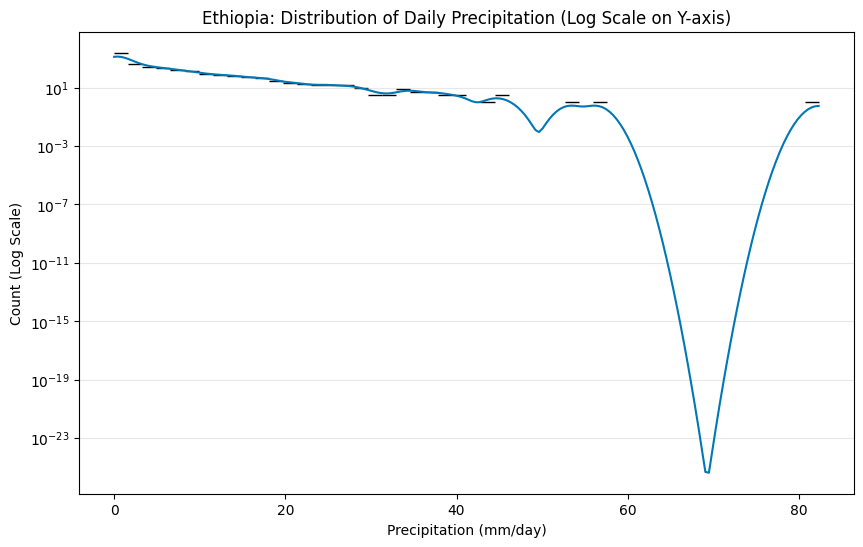

In [ ]:
plt.figure(figsize=(10, 6))
sns.histplot(df['PRECTOTCORR'], bins=50, kde=True, color='#0077b6', log_scale=(False, True))

plt.title('Sudan: Distribution of Daily Precipitation (Log Scale on Y-axis)')
plt.xlabel('Precipitation (mm/day)')
plt.ylabel('Count (Log Scale)')
plt.grid(axis='y', alpha=0.3)
plt.show()

##### Interpretation of Rainfall Distribution
* Distribution: Ultra-right-skewed. Extreme "zero-inflation" shows most days are bone-dry, with rare, violent flash floods.

* Policy Insight: Focus on Sand Dams and Groundwater Recharge. Since rain is rare but intense, capturing runoff immediately is the only way to prevent total evaporation.




-Bubble Chart (Temp vs. Humidity vs. Rain)

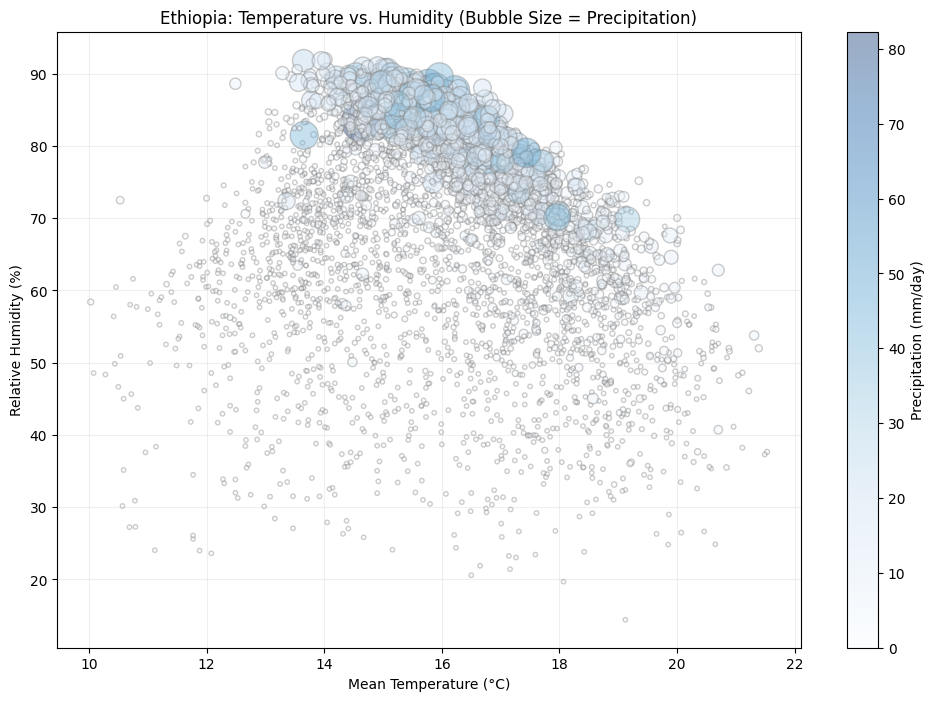

In [ ]:
plt.figure(figsize=(12, 8))
bubble_size = (df['PRECTOTCORR'] + 1) * 10 

scatter = plt.scatter(
    data=df, 
    x='T2M', 
    y='RH2M', 
    s=bubble_size, 
    alpha=0.4, 
    c='PRECTOTCORR', 
    cmap='Blues', 
    edgecolors='grey'
)

# Add a colorbar to show rain intensity
plt.colorbar(scatter, label='Precipitation (mm/day)')

plt.title('Sudan: Temperature vs. Humidity (Bubble Size = Precipitation)')
plt.xlabel('Mean Temperature (°C)')
plt.ylabel('Relative Humidity (%)')
plt.grid(alpha=0.2)
plt.show()

##### Bubble Chart Interpretation

* Rainfall Clusters: Large bubbles are rare and tightly grouped in a short July–August window, confirming a brief, intense monsoon.
* Dry Heat: A massive concentration of small bubbles in the High Temp / Low Humidity zone represents the dominant "Hot-Dry" desert climate.
* Anomalies: Large bubbles at temperatures $>38°C$ indicate extreme convective storms that cause devastating flash floods in parched areas.